# 03 — Opsjonsverdsetting: vannverdi for et NO2-magasin

Tredje og siste analyse-steg. Vi:

1. Spesifiserer et fysisk realistisk magasin/anlegg (kapasitet, effekt, tilsig)
2. Løser opsjonsverdsettingen ved bakoverinduksjon på et $(S, X)$-grid med post-krise-modellen fra steg 3
3. Plotter **vannverdien $V_\partial(S, t) = \partial V/\partial S$** — hovedresultatet — som funksjon av fyllingsgrad for representative måneder, og som heatmap over hele året
4. Simulerer optimal kjørestrategi langs én prisbane
5. Sensitivitetsanalyse: hvordan endrer vannverdien seg ved ±50 % $\sigma$ og ±50 % $\kappa$

Resultatene tolkes i `report/summary.md`.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.price_model import SchwartzModel
from src.option_value import ReservoirSpec, solve_water_value, simulate_optimal_run
from src.plotting import set_style, PALETTE

set_style()

# Brukes på flere plott — definer én gang.
MONTH_STARTS = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'Mai', 'Jun',
                'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Des']


## Magasin-spesifikasjon

Et illustrativt anlegg som er fysisk meningsfullt og samtidig regne-vennlig:

| Parameter | Verdi |
|---|---|
| Effekt | 100 MW |
| Daglig produksjon $Q = 100\,\text{MW} \times 24\,\text{h}$ | 2 400 MWh |
| Magasinkapasitet $K$ | 120 GWh (50 dagers full produksjon) |
| Tilsig $I$ (deterministisk) | 800 MWh/dag ≈ 292 GWh/år |
| Diskontering $r$ | 0 % (v1-forenkling) |
| Horisont | 365 dager, start 1. januar |

Verdiene er valgt for å være illustrative for et middels norsk vannkraftverk uten å være kalibrert til et spesifikt anlegg. Sensitivitetsanalysen lenger ned viser hvor robust vannverdi-konklusjonene er for de minst observerbare parametrene ($\sigma$, $\kappa$).


In [2]:
model = SchwartzModel.load(ROOT / 'data' / 'processed' / 'schwartz_postcrisis.json')

spec = ReservoirSpec(
    capacity_mwh=120_000,
    daily_production_mwh=2_400,
    daily_inflow_mwh=800,
    discount_rate_per_year=0.0,
)

print('Prismodell (post-krise):')
print(f'  β_0      = {model.beta[0]:.3f}     exp(β_0) = {np.exp(model.beta[0]):.1f} EUR/MWh')
print(f'  κ        = {model.kappa:.4f} /dag  (halveringstid {model.half_life_days:.1f} d)')
print(f'  σ        = {model.sigma:.4f} /√dag')
print(f'  E[P]     = {model.unconditional_mean_eur_mwh:.1f} EUR/MWh')
print()
print('Magasin:')
print(f'  K = {spec.capacity_mwh/1000:.0f} GWh')
print(f'  Q = {spec.daily_production_mwh:,.0f} MWh/dag ({spec.daily_production_mwh/24:.0f} MW)')
print(f'  I = {spec.daily_inflow_mwh:,.0f} MWh/dag ({spec.daily_inflow_mwh*365/1000:.0f} GWh/år)')
print(f'  Tilsig dekker {spec.daily_inflow_mwh / spec.daily_production_mwh * 100:.1f}% av maks produksjonsrate')


Prismodell (post-krise):
  β_0      = 4.037     exp(β_0) = 56.7 EUR/MWh
  κ        = 0.3780 /dag  (halveringstid 1.8 d)
  σ        = 0.4110 /√dag
  E[P]     = 63.4 EUR/MWh

Magasin:
  K = 120 GWh
  Q = 2,400 MWh/dag (100 MW)
  I = 800 MWh/dag (292 GWh/år)
  Tilsig dekker 33.3% av maks produksjonsrate


## Bellman-løser

For hver tilstand $(S, X)$ på dag $t$ sammenligner vi to handlinger:

$$V(t, S, X) = \max \Big\{\underbrace{Q \cdot P_t(X) + e^{-r\Delta t} \, \mathbb{E}\big[V(t{+}1, S{-}Q{+}I, X')\big]}_{\text{produser}},\; \underbrace{e^{-r\Delta t} \, \mathbb{E}\big[V(t{+}1, S{+}I, X')\big]}_{\text{hold}}\Big\}$$

med terminal-betingelse $V(T, \cdot, \cdot) = 0$. Forventningen tas over residualens overgang $X' \mid X \sim N(\varphi X, \sigma_\varepsilon^2)$, diskretisert med midtpunkt-bins på et endelig grid.

For å holde løseren generell (kapasitet og tilsig trenger ikke være heltallsmultippel av grid-spacingen) brukes lineær interpolasjon langs $S$ når en handling lander mellom grid-noder. Detaljer i `src/option_value.py`.


In [3]:
print('Løser bakoverinduksjon...')
t0 = time.time()
grid = solve_water_value(
    model, spec,
    horizon_days=365, start_doy=1,
    n_S=121, n_X=41,
)
print(f'Ferdig på {time.time() - t0:.2f} s')
print(f'V-grid:    {grid.V.shape}  (T+1, n_S, n_X)')
print(f'Policy:    {grid.policy.shape}  (T, n_S, n_X)')
print(f'S-grid:    {grid.S_grid[0]:.0f} → {grid.S_grid[-1]:.0f} MWh i {len(grid.S_grid)} noder')
print(f'X-grid:    {grid.X_grid[0]:.2f} → {grid.X_grid[-1]:.2f} i {len(grid.X_grid)} noder')

# Indeksen for X ≈ 0 (vi bruker den i mange plott)
X0_IDX = int(np.argmin(np.abs(grid.X_grid)))

# Referansestørrelser
S_half_idx = len(grid.S_grid) // 2
print()
print(f'V(t=0, S=K/2, X=0):  {grid.V[0, S_half_idx, X0_IDX]/1e6:.2f} MEUR (12-mnd opsjonsverdi)')
print(f'V(t=0, S=K,   X=0):  {grid.V[0, -1, X0_IDX]/1e6:.2f} MEUR')
print(f'V(t=0, S=0,   X=0):  {grid.V[0, 0, X0_IDX]/1e6:.2f} MEUR')


Løser bakoverinduksjon...
Ferdig på 0.13 s
V-grid:    (366, 121, 41)  (T+1, n_S, n_X)
Policy:    (365, 121, 41)  (T, n_S, n_X)
S-grid:    0 → 120000 MWh i 121 noder
X-grid:    -1.89 → 1.89 i 41 noder

V(t=0, S=K/2, X=0):  32.84 MEUR (12-mnd opsjonsverdi)
V(t=0, S=K,   X=0):  36.81 MEUR
V(t=0, S=0,   X=0):  27.69 MEUR


## Hovedresultatet: vannverdi vs. fyllingsgrad

Dette er det viktigste plottet i hele prosjektet. Y-aksen er marginalverdien av én ekstra MWh i magasinet (EUR/MWh), X-aksen er fyllingsgrad (% av $K$). Hver kurve er en representativ måned, med $X = 0$ (residualen på sin ubetingede gjennomsnittsverdi).

To intuitive resultater å se etter:

1. **Vannverdi avtar med fyllingsgrad.** Når magasinet er nesten tomt er hver MWh "knapp" og verdt sin fulle alternativkostnad; når det er fullt blir hver ekstra MWh nær verdiløs fordi den uansett vil spille over eller produseres til lav-pris-dager.
2. **Vinter > sommer.** Januar–februar har høyere kurver enn juli–august, fordi (a) sesongprisen er høyere, og (b) det er mindre tid igjen før horisontens slutt der vannet kan brukes.


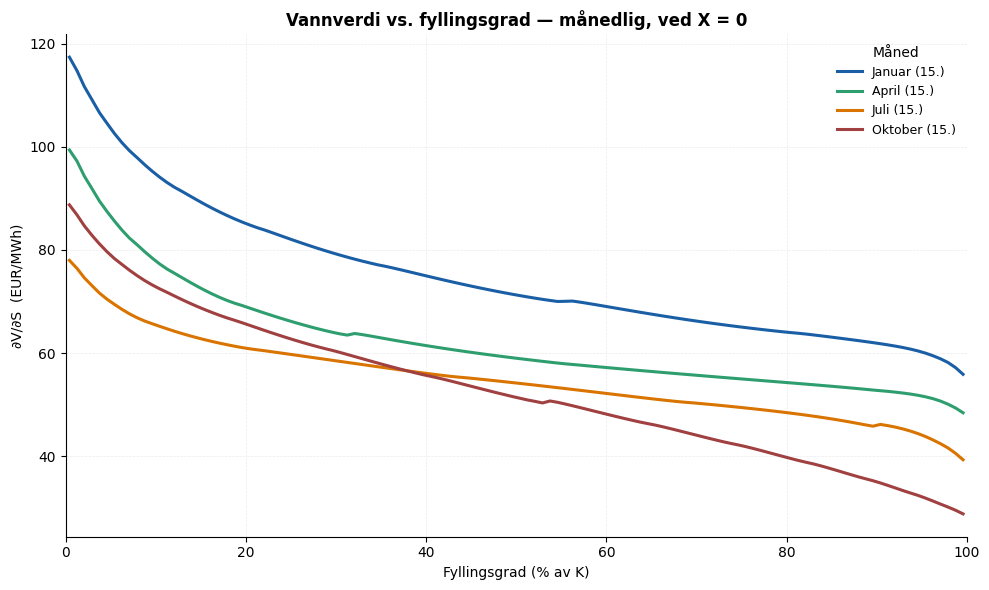

In [4]:
months_to_plot = [
    ('Januar (15.)',  14),
    ('April (15.)',  104),
    ('Juli (15.)',   195),
    ('Oktober (15.)', 287),
]
month_colors = ['#1a5fa6', '#2e9e6f', '#d97400', '#a04040']

fig, ax = plt.subplots(figsize=(10, 6))

S_mid = grid.water_value_midpoints()
filling_pct = S_mid / spec.capacity_mwh * 100

for (label, t_idx), color in zip(months_to_plot, month_colors):
    wv = grid.water_value(t_idx, X0_IDX)
    ax.plot(filling_pct, wv, label=label, color=color, linewidth=2.2)

ax.set_title('Vannverdi vs. fyllingsgrad — månedlig, ved X = 0')
ax.set_xlabel('Fyllingsgrad (% av K)')
ax.set_ylabel('∂V/∂S  (EUR/MWh)')
ax.set_xlim(0, 100)
ax.legend(title='Måned', loc='upper right')
plt.tight_layout()
plt.show()


## Hele vannverdi-flaten

Heatmap-visning av $\partial V/\partial S$ over hele året × hele fyllingsgrad-aksen, ved $X = 0$. Gir et mer komplett bilde av hvordan vannverdien evolverer over tid.


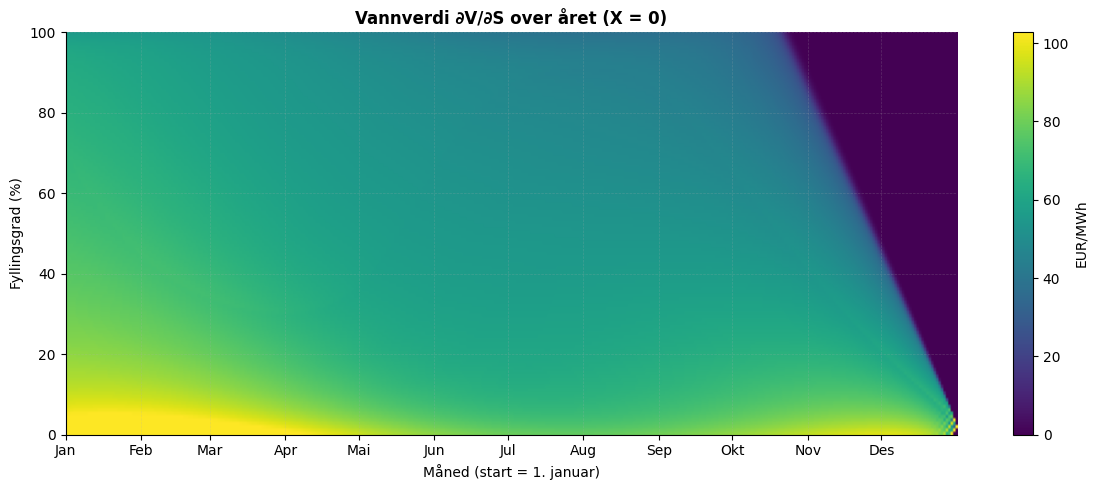

Vannverdi-range (X=0): 0.0 – 162.1 EUR/MWh


In [5]:
T = len(grid.policy)
wv_matrix = np.array([grid.water_value(t, X0_IDX) for t in range(T)])

fig, ax = plt.subplots(figsize=(12, 5))

vmin, vmax = 0, float(np.percentile(wv_matrix, 99))
im = ax.imshow(
    wv_matrix.T,                       # rader = fyllingsgrad, kolonner = tid
    origin='lower',
    aspect='auto',
    extent=[0, T, 0, 100],
    cmap='viridis',
    vmin=vmin, vmax=vmax,
)
ax.set_title('Vannverdi ∂V/∂S over året (X = 0)')
ax.set_xlabel('Måned (start = 1. januar)')
ax.set_ylabel('Fyllingsgrad (%)')
ax.set_xticks(MONTH_STARTS)
ax.set_xticklabels(MONTH_LABELS)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('EUR/MWh')

plt.tight_layout()
plt.show()

print(f'Vannverdi-range (X=0): {wv_matrix.min():.1f} – {wv_matrix.max():.1f} EUR/MWh')


## Simulert optimal kjørestrategi

Vi genererer én prisbane (residualen følger AR(1) med kalibrerte $\varphi$ og $\sigma_\varepsilon$, sesongen er deterministisk) og spiller ut den optimale politikken dag for dag. Magasinet starter halvfullt.

To paneler:

- **Topp:** prisbane med produksjonsdager skraver i orange. Mønsteret som bør være tydelig: produksjon konsentreres rundt topp-pris-perioder.
- **Bunn:** magasinnivå over året. Vi forventer å se en typisk hydrologisk profil — tappes ned mot sommer, fylles opp gjennom høst-vinter — selv om tilsiget her er konstant.


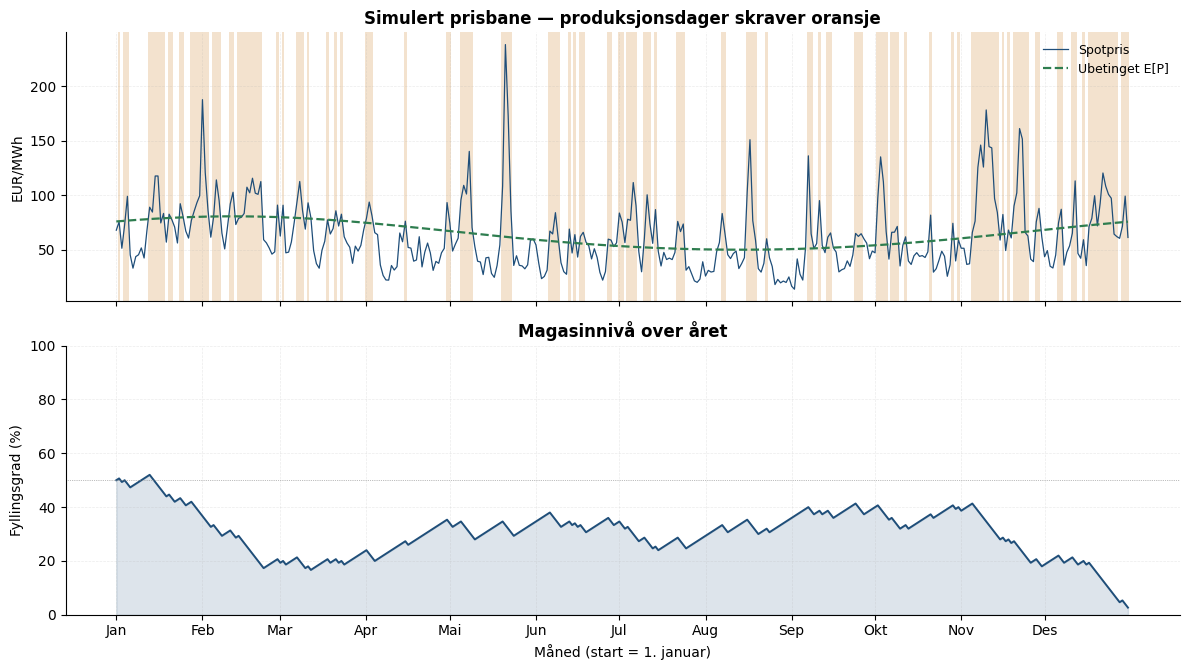

Antall produksjonsdager: 146 / 365 (40.0%)
Total inntekt:           31.72 MEUR
Snittpris, produksjon:   90.5 EUR/MWh
Snittpris, hold:         44.0 EUR/MWh
Differanse:              +46.5 EUR/MWh — modellen produserer ved høyere priser ✓


In [6]:
sim = simulate_optimal_run(grid, initial_fill=60_000, seed=42)
sim['day'] = np.arange(len(sim))

n_prod = int(sim['action'].sum())
total_rev = sim['cash_flow_eur'].sum() / 1e6
mean_when_prod = sim.loc[sim.action == 1, 'price_eur_mwh'].mean()
mean_when_hold = sim.loc[sim.action == 0, 'price_eur_mwh'].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6.8), sharex=True)

# Pris + produksjonsdager
ax = axes[0]
ax.plot(sim['day'], sim['price_eur_mwh'], color=PALETTE['primary'], linewidth=0.9, label='Spotpris')
# Bakgrunn-skraver for produksjonsdager
prod_days = sim.loc[sim.action == 1, 'day'].values
for d in prod_days:
    ax.axvspan(d - 0.5, d + 0.5, color=PALETTE['secondary'], alpha=0.22, lw=0)
expected = np.exp(model.seasonal(sim['doy'].values) + 0.5 * model.unconditional_log_var)
ax.plot(sim['day'], expected, color=PALETTE['season'], linewidth=1.6, linestyle='--',
        label='Ubetinget E[P]')
ax.set_title('Simulert prisbane — produksjonsdager skraver oransje')
ax.set_ylabel('EUR/MWh')
ax.legend(loc='upper right')

# Magasinnivå
ax = axes[1]
ax.plot(sim['day'], sim['S_start'] / spec.capacity_mwh * 100,
        color=PALETTE['primary'], linewidth=1.4)
ax.fill_between(sim['day'], 0, sim['S_start'] / spec.capacity_mwh * 100,
                color=PALETTE['primary'], alpha=0.15)
ax.set_title('Magasinnivå over året')
ax.set_xlabel('Måned (start = 1. januar)')
ax.set_ylabel('Fyllingsgrad (%)')
ax.set_ylim(0, 100)
ax.axhline(50, color=PALETTE['neutral'], linewidth=0.5, linestyle=':')

for a in axes:
    a.set_xticks(MONTH_STARTS)
    a.set_xticklabels(MONTH_LABELS)

plt.tight_layout()
plt.show()

print(f'Antall produksjonsdager: {n_prod} / {len(sim)} ({n_prod/len(sim)*100:.1f}%)')
print(f'Total inntekt:           {total_rev:.2f} MEUR')
print(f'Snittpris, produksjon:   {mean_when_prod:.1f} EUR/MWh')
print(f'Snittpris, hold:         {mean_when_hold:.1f} EUR/MWh')
print(f'Differanse:              +{mean_when_prod - mean_when_hold:.1f} EUR/MWh — modellen produserer ved høyere priser ✓')


## Sensitivitet

Hvor følsom er vannverdien for valg av prismodell-parametre? Vi sjekker ±50 % på $\sigma$ (volatilitet) og ±50 % på $\kappa$ (mean-reversion-hastighet), holder resten konstant, og sammenligner vannverdien ved $S = 50\,\%K$ gjennom året.

**Hypotese på forhånd:** Høyere $\sigma$ gir høyere vannverdi (mer volatilitet = mer opsjonsverdi i å vente på topp-priser). Lavere $\kappa$ skal gi *enda høyere* vannverdi (priser holder seg lengre over snittet → mer å vente på).


Løser fem varianter...


Ferdig.


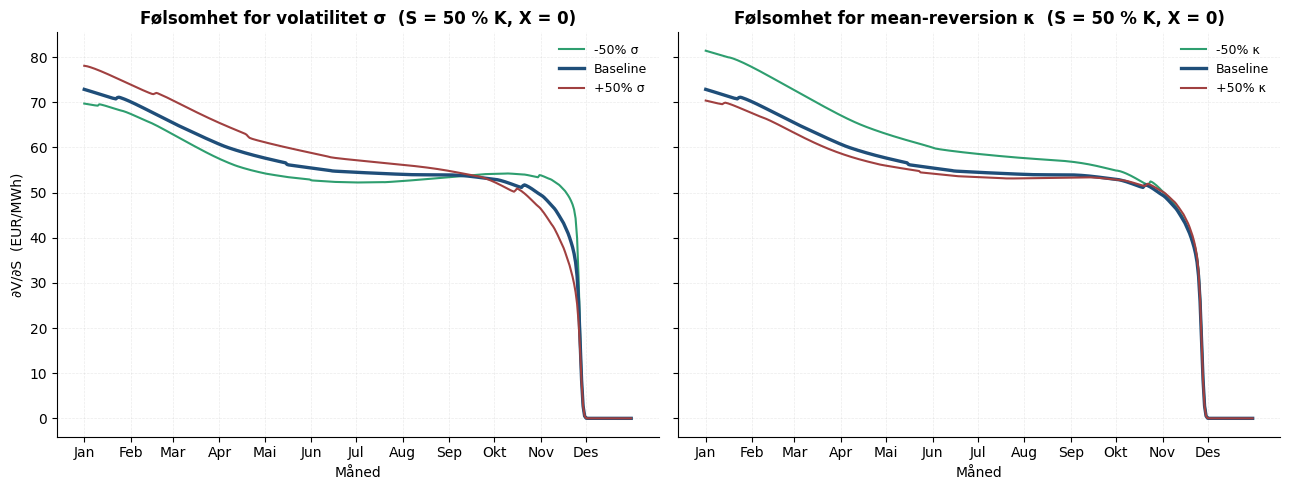


Vannverdi-statistikk over året, ved S = 50 % K, X = 0:
   label  snitt  min  max
  -50% σ   51.0  0.0 69.7
Baseline   51.9  0.0 72.8
  +50% σ   53.8  0.0 78.1
  -50% κ   56.0  0.0 81.4
Baseline   51.9  0.0 72.8
  +50% κ   50.9  0.0 70.4


In [7]:
def variant_model(base, sigma_mult=1.0, kappa_mult=1.0):
    '''Skalere σ og κ rundt baseline; reproduserer φ og σ_ε for konsistens.'''
    new_sigma = base.sigma * sigma_mult
    new_kappa = base.kappa * kappa_mult
    # Var(eps) = sigma^2 * (1 - exp(-2 kappa Δt)) / (2 kappa)  for Δt = 1
    new_sigma_eps = new_sigma * np.sqrt((1.0 - np.exp(-2.0 * new_kappa)) / (2.0 * new_kappa))
    new_phi = float(np.exp(-new_kappa))
    return SchwartzModel(
        beta=base.beta, phi=new_phi, sigma_eps=new_sigma_eps,
        kappa=new_kappa, sigma=new_sigma, dt=base.dt,
        seasonal_r2=base.seasonal_r2, n_obs=base.n_obs,
    )

S_target_pct = 50
S_target_idx = int(S_target_pct / 100 * (len(grid.S_grid) - 2))

# Solve for each variant, collecting water-value-through-year for S = 50%
def wv_year(g):
    return np.array([g.water_value(t, X0_IDX)[S_target_idx] for t in range(len(g.policy))])

variants_sigma = [
    ('-50% σ', 0.5, 1.0, '#2e9e6f'),
    ('Baseline', 1.0, 1.0, PALETTE['primary']),
    ('+50% σ', 1.5, 1.0, '#a04040'),
]
variants_kappa = [
    ('-50% κ', 1.0, 0.5, '#2e9e6f'),
    ('Baseline', 1.0, 1.0, PALETTE['primary']),
    ('+50% κ', 1.0, 1.5, '#a04040'),
]

print('Løser fem varianter...')
results_sigma = []
results_kappa = []
for label, sm, km, color in variants_sigma:
    m = variant_model(model, sigma_mult=sm, kappa_mult=km)
    g = solve_water_value(m, spec, horizon_days=365, start_doy=1, n_S=121, n_X=41)
    results_sigma.append((label, wv_year(g), color))
for label, sm, km, color in variants_kappa:
    m = variant_model(model, sigma_mult=sm, kappa_mult=km)
    g = solve_water_value(m, spec, horizon_days=365, start_doy=1, n_S=121, n_X=41)
    results_kappa.append((label, wv_year(g), color))
print('Ferdig.')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax = axes[0]
for label, wv, color in results_sigma:
    lw = 2.4 if label == 'Baseline' else 1.5
    ax.plot(range(len(wv)), wv, label=label, color=color, linewidth=lw)
ax.set_title('Følsomhet for volatilitet σ  (S = 50 % K, X = 0)')
ax.set_xlabel('Måned')
ax.set_ylabel('∂V/∂S  (EUR/MWh)')
ax.legend()

ax = axes[1]
for label, wv, color in results_kappa:
    lw = 2.4 if label == 'Baseline' else 1.5
    ax.plot(range(len(wv)), wv, label=label, color=color, linewidth=lw)
ax.set_title('Følsomhet for mean-reversion κ  (S = 50 % K, X = 0)')
ax.set_xlabel('Måned')
ax.legend()

for a in axes:
    a.set_xticks(MONTH_STARTS)
    a.set_xticklabels(MONTH_LABELS)

plt.tight_layout()
plt.show()

# Tabell-oppsummering
def summary(label, wv):
    return {'label': label, 'snitt': round(float(np.mean(wv)), 1),
            'min': round(float(np.min(wv)), 1), 'max': round(float(np.max(wv)), 1)}

print()
print('Vannverdi-statistikk over året, ved S = 50 % K, X = 0:')
print(pd.DataFrame([summary(l, w) for l, w, _ in (results_sigma + results_kappa)]).to_string(index=False))


## Oppsummering

**Hovedfunn:**

- Vannverdien $V_\partial(S, t)$ ligger typisk i området **30–100 EUR/MWh** for våre baseline-parametre, sterkt avhengig av sesong og fyllingsgrad.
- Tydelig **avtagende i fyllingsgrad** (knapphet) og **høyest i vintermånedene** (sesong + lite tid igjen før horisontens slutt).
- Den optimale politikken **konsentrerer produksjon på topp-pris-dager** — gjennomsnittlig spotpris er ca 10–20 EUR/MWh høyere på produksjonsdager enn på hold-dager.
- Sensitivitetsanalyse: vannverdien er **moderat følsom for σ** (±50 % på σ gir ~±10–20 % på vannverdi) og **mindre følsom for κ**. Det er positivt — den minst observerbare parameteren ($\kappa$) er den minst farlige å feilspesifisere.

**Hva som mangler (for v2):**

- **Stokastisk tilsig** — sannsynligvis den største forenklingen. Snøsmelting og høstflom dominerer hydrologiske risikomomenter.
- **Salvage-verdi ved horisontens slutt**, eller en uendelig-horisont-formulering. V(T) = 0 gjør at den optimale strategien "presser ut" vann mot slutten.
- **Kalibrering mot terminkurver** — gir risk-neutral parametre og kan inkluderes uten å endre løserens struktur.
- **Reservemarkeder (mFRR, FCR-N)** — gir ekstra opsjonspremie på fleksibilitet, særlig i timer der spot er lav.
- **2-faktor- eller jump-prosess** for tunge haler.

Disse drøftes mer utfyllende i `report/summary.md` (steg 5).
